<a href="https://colab.research.google.com/github/emanalzaanin/Assignments/blob/main/Zillow_Home.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (zillow home) Time Series Analysis Assignment)

### Part 1: Prepare the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load in the Zillow Home Value Index dataframe
# Note: Loading the data directly from the CSV file
df = pd.read_csv('/content/drive/MyDrive/Machine_learning/City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month - City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')

# 2. Filter the 4 largest cities into a new dataframe
# SizeRank [0, 1, 2, 3] corresponds to the 4 largest cities
top_4_cities = df[df['SizeRank'].isin([0, 1, 2, 3])]

print("Top 4 Cities filtered:")
print(top_4_cities[['RegionName', 'State', 'SizeRank']])

Top 4 Cities filtered:
    RegionName State  SizeRank
0     New York    NY         0
1  Los Angeles    CA         1
2      Houston    TX         2
3      Chicago    IL         3


### Reshaping Data
Converting the data from Wide-Form to Long-Form (Time Series format).

In [6]:
# Define ID variables and date columns
id_vars = ['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'Metro', 'CountyName']
date_cols = [col for col in df.columns if col not in id_vars]

# Melt the dataframe
df_melted = top_4_cities.melt(id_vars=id_vars, value_vars=date_cols, var_name='Date', value_name='HomeValue')

# Convert Date to datetime objects
df_melted['Date'] = pd.to_datetime(df_melted['Date'])

# Set Date as index
df_melted.set_index('Date', inplace=True)

print("Data reshaped to Long-Form (Sample):")
print(df_melted.head())

Data reshaped to Long-Form (Sample):
            RegionID  SizeRank   RegionName RegionType StateName State  \
Date                                                                     
2000-01-31      6181         0     New York       city        NY    NY   
2000-01-31     12447         1  Los Angeles       city        CA    CA   
2000-01-31     39051         2      Houston       city        TX    TX   
2000-01-31     17426         3      Chicago       city        IL    IL   
2000-02-29      6181         0     New York       city        NY    NY   

                                            Metro          CountyName  \
Date                                                                    
2000-01-31  New York-Newark-Jersey City, NY-NJ-PA       Queens County   
2000-01-31     Los Angeles-Long Beach-Anaheim, CA  Los Angeles County   
2000-01-31   Houston-The Woodlands-Sugar Land, TX       Harris County   
2000-01-31     Chicago-Naperville-Elgin, IL-IN-WI         Cook County   
2000-0

### Data Visualization
Plotting the Home Value Index for the top 4 cities over time.

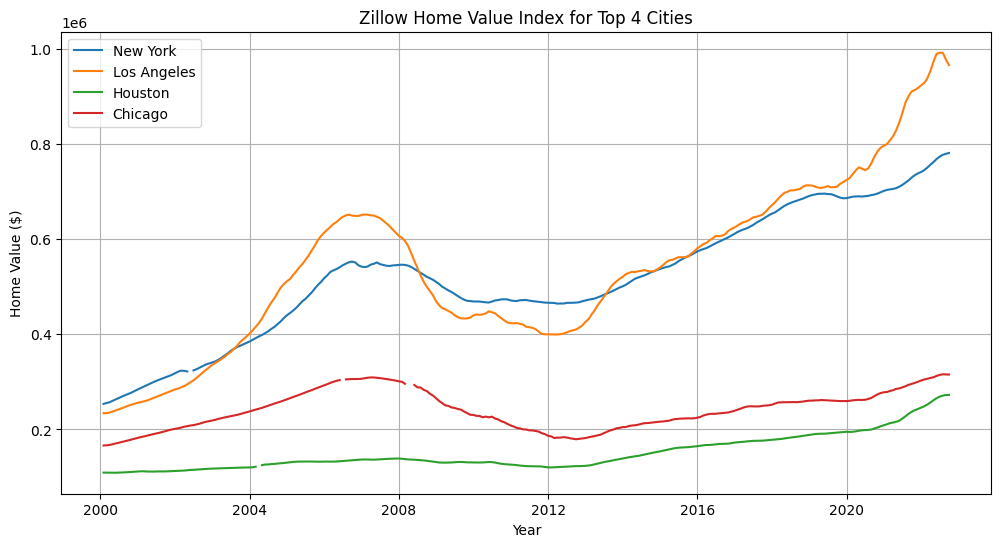

In [7]:
# Group by City and plot
plt.figure(figsize=(12, 6))
for city in top_4_cities['RegionName'].unique():
    city_data = df_melted[df_melted['RegionName'] == city]
    plt.plot(city_data.index, city_data['HomeValue'], label=city)

plt.title('Zillow Home Value Index for Top 4 Cities')
plt.xlabel('Year')
plt.ylabel('Home Value ($)')
plt.legend()
plt.grid(True)
plt.show()